# COM31006 Computer Vision Assignment 
Adam Willis | acc22aw

Imports
-

In [67]:
from torchvision import datasets, transforms
import hashlib
import matplotlib.pyplot as plt
import random

PART I - Dataset
-

In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()

    # TODO - look into normalization and ImageNet pretrained mean and sd
])

train_dataset = datasets.ImageFolder('dataset/train', transform=transform)
test_dataset = datasets.ImageFolder('dataset/test', transform=transform)

In [35]:
train_total = len(train_dataset)
test_total = len(test_dataset)
total = train_total + test_total

In [36]:
def dataset_summary():
    print(f"Dataset Domain: Household Items\n{'-'*50}")
    print("dataset/")

    print("  train/")
    for cls, id in train_dataset.class_to_idx.items():
        print(f"    {cls}/")
        print(f"      {train_dataset.targets.count(id)} images")

    print("  test/")
    for cls, id in test_dataset.class_to_idx.items():
        print(f"    {cls}/")
        print(f"      {test_dataset.targets.count(id)} images")

    print('-'*50)
    print(f"Total Images: {total}")
    print(f"Train / Test: {train_total} ({train_total/total*100}%) / {test_total} ({test_total/total*100}%)")

dataset_summary()

Dataset Domain: Household Items
--------------------------------------------------
dataset/
  train/
    book/
      64 images
    bottle/
      64 images
    cutlery/
      64 images
    mug/
      64 images
    shoe/
      64 images
  test/
    book/
      16 images
    bottle/
      16 images
    cutlery/
      16 images
    mug/
      16 images
    shoe/
      16 images
--------------------------------------------------
Total Images: 400
Train / Test: 320 (80.0%) / 80 (20.0%)


In [64]:
# Dataset Validation - checks for overlaps (non-unique or reused images) in train and test sets by comparing image hashes
# TODO - consider perceptual hashing to show the strength of the dataset (proves i focused on quality as well as quantity)

def convert_to_hashes(dataset):
    hashes = set()

    for i in range(len(dataset)):
        img, _ = dataset[i]
        img_hash = hashlib.sha256(img.numpy().tobytes()).hexdigest()
        hashes.add(img_hash)
    
    return hashes

train_dataset_hashed = convert_to_hashes(train_dataset)
test_dataset_hashed = convert_to_hashes(test_dataset)
overlap = train_dataset_hashed.intersection(test_dataset_hashed)

train_hash_total = len(train_dataset_hashed)
test_hash_total = len(test_dataset_hashed)

print(f"Train -> Unique Hashes / Total Images: {train_hash_total} / {train_total}")
print(f" Test -> Unique Hashes / Total Images:  {test_hash_total} /  {test_total}")
print(f"Total -> Unique Hashes / Total Images: {train_hash_total+test_hash_total} / {total}")
print(f"{'-'*50}\nTrain / Test Overlap: {len(overlap)}\n{'-'*50}")
if (not len(overlap)): print("Valid Dataset")

Train -> Unique Hashes / Total Images: 320 / 320
 Test -> Unique Hashes / Total Images:  80 /  80
Total -> Unique Hashes / Total Images: 400 / 400
--------------------------------------------------
Train / Test Overlap: 0
--------------------------------------------------
Valid Dataset


In [ ]:
# TODO - clean up and remove unnecessary bits and bobs

def show_class_samples(dataset, num=3):
    random.seed(20)

    class_to_indices = {i: [] for i in range(len(dataset.classes))}

    # group indices by class
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        class_to_indices[label].append(idx)

    num_classes = len(dataset.classes)

    # SWAPPED: rows = k, cols = num_classes
    plt.figure(figsize=(num_classes * 3, num * 3))

    for class_idx, class_name in enumerate(dataset.classes):
        indices = class_to_indices[class_idx]
        chosen = random.sample(indices, min(num, len(indices)))

        for j, idx in enumerate(chosen):
            img, label = dataset[idx]
            img = img.permute(1, 2, 0)

            # swapped indexing:
            # row = j (sample index)
            # col = class_idx
            plt.subplot(num, num_classes, j * num_classes + class_idx + 1)
            plt.imshow(img)
            plt.title(class_name if j == 0 else "")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

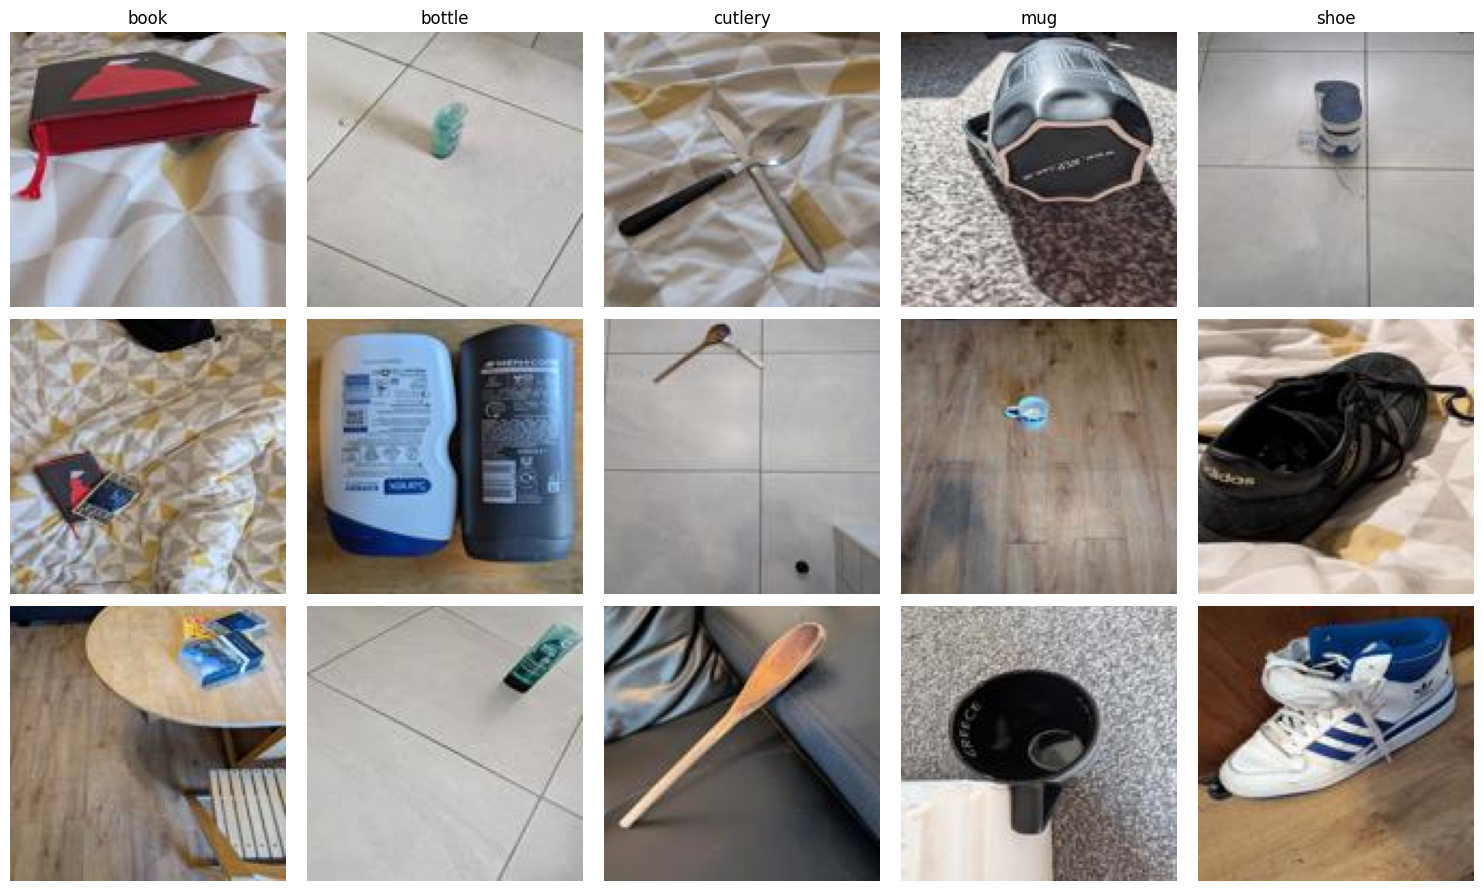

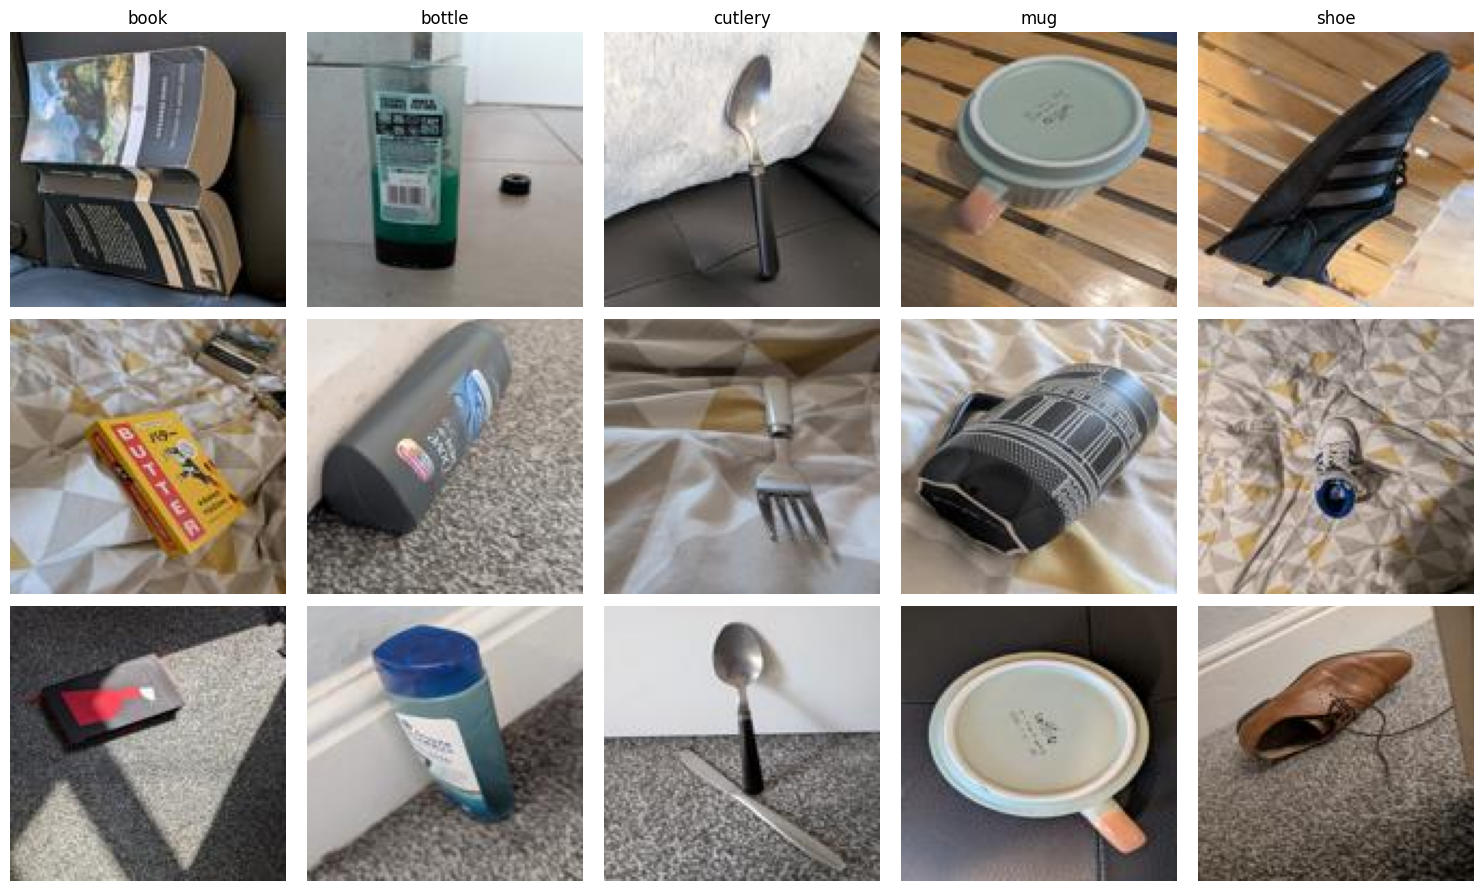

In [73]:
show_class_samples(train_dataset, 3)
show_class_samples(test_dataset, 3)

In [ ]:
# TODO - train set augmentation here - Random horizontal flip, Rotation, Color jitter

PART II - Exploring AlexNet
-

PART III - Comparing Classical Filters
-

PART IV - Modifying Architecture using Filter Selection
-

PART V - Comparison and Evaluation
-